# Part 8: Flax Basics

In [1]:
# @title Setup { display-mode: "form" }

import jax
import jax.numpy as jnp
import numpy as np
import flax.linen as nn
import matplotlib.pyplot as plt

print(f"JAX version:     {jax.__version__}")
print(f"Devices:         {jax.devices()}")
print(f"Default backend: {jax.default_backend()}")

JAX version:     0.9.2
Devices:         [CpuDevice(id=0)]
Default backend: cpu


In [2]:
# @title Shared Data from Notebook 07 { display-mode: "form" }

# Dataset - two interleaved half-moons (same as Notebook 07)
key = jax.random.key(42)

def make_moons(n_samples=1000, noise=0.15, seed=0):
    rng = np.random.default_rng(seed)
    n = n_samples // 2
    t = np.linspace(0, np.pi, n)
    X0 = np.c_[np.cos(t), np.sin(t)]
    X1 = np.c_[1 - np.cos(t), 1 - np.sin(t) - 0.5]
    X = np.vstack([X0, X1]) + rng.normal(scale=noise, size=(n_samples, 2))
    y = np.hstack([np.zeros(n), np.ones(n)])
    return X.astype(np.float32), y.astype(np.float32)

X_np, y_np = make_moons(n_samples=1000, noise=0.15, seed=0)
X = jnp.array(X_np)
y = jnp.array(y_np)

print(f"Dataset: {X.shape}, labels: {y.shape}")

Dataset: (1000, 2), labels: (1000,)


---

# 1. Training with Flax

## 1.1 The `init` / `apply` Pattern

```python
model     = MyMLP(...)                       # Define architecture (no weights yet)
variables = model.init(key, x_dummy)         # Create the weight pytree
params    = variables['params']              # Extract the params subtree

output    = model.apply({'params': params}, x)  # Pure forward pass
```

The two-step split is intentional: `init` needs a PRNG key (to generate initial weights), `apply` is a pure function with no randomness (at inference time). This keeps both steps compatible with `jit`, `grad`, and `vmap`.

`variables` is a dict whose top-level keys are the *kinds* of state your model has. The most common key is `'params'` (trainable weights). Models that use batch normalization get a second key called `'batch_stats'` (running averages of activations), but we won't need that here.

```
  model = MyMLP(...)          ← describes architecture only, no weights yet
       │
       │     ┌──► model.init(key, x_dummy)
       │     │       run once: traces a forward pass to discover layer shapes
       │     │       returns: variables = {'params': nested pytree of arrays}
       │     │
       │     │            params = variables['params']
       │     │                    │
       │     │                    ▼
       │     │       ┌─────────────────────────────────┐
       └─────┴──────►│ model.apply({'params': params}, x) │──► output
                     └─────────────────────────────────┘
                       pure function - safe to jit / grad / vmap
                       call as many times as you want with the same params
```

## 1.2 `@nn.compact`

The `@nn.compact` decorator lets you declare layers *inline*: you write `nn.Dense(h)(x)` right at the spot where the layer is used, and Flax figures out the layer's input shape automatically.

(Flax also has a more verbose style where you list layers in a separate `setup()` method and reference them by attribute. `@nn.compact` is the simpler form and is what most Flax tutorials use.)

On the first call to `model.init`, Flax runs `__call__` once with the dummy input to discover which layers you created and what shapes they need, then allocates the weights. Subsequent calls reuse them.

In [3]:
# Define the same MLP architecture using Flax
class MLP(nn.Module):
    hidden_sizes: tuple
    out_size: int = 1

    @nn.compact
    def __call__(self, x):
        for h in self.hidden_sizes:
            x = nn.Dense(h)(x)
            x = nn.relu(x)
        return nn.Dense(self.out_size)(x).squeeze(-1)

# Create model and initialize
model = MLP(hidden_sizes=(64, 64))

key, subkey = jax.random.split(key)
x_dummy = jnp.ones((1, 2))                     # dummy input to infer shapes
variables = model.init(subkey, x_dummy)
params_flax = variables['params']

# Inspect: still just a nested dict!
print("params_flax structure:")
for layer, vals in params_flax.items():
    for name, arr in vals.items():
        print(f"  {layer}/{name}: shape={arr.shape}")

params_flax structure:
  Dense_0/kernel: shape=(2, 64)
  Dense_0/bias: shape=(64,)
  Dense_1/kernel: shape=(64, 64)
  Dense_1/bias: shape=(64,)
  Dense_2/kernel: shape=(64, 1)
  Dense_2/bias: shape=(1,)


In [4]:
# Loss function wraps model.apply - identical structure to the scratch version
def loss_flax(params, x_batch, y_batch):
    logits = model.apply({'params': params}, x_batch)  # batched by default in Flax
    return jnp.mean(
        jnp.maximum(logits, 0) - logits * y_batch + jnp.log(1 + jnp.exp(-jnp.abs(logits)))
    )

# Training step - IDENTICAL to the scratch version (params is still a pytree)
@jax.jit
def train_step_flax(params, x_batch, y_batch, lr=0.05):
    loss, grads = jax.value_and_grad(loss_flax)(params, x_batch, y_batch)
    new_params = jax.tree.map(lambda p, g: p - lr * g, params, grads)
    return new_params, loss

# Train (each iteration is one gradient step on a random mini-batch)
losses_flax = []
for step in range(200):
    key, subkey = jax.random.split(key)
    idx = jax.random.permutation(subkey, len(X))[:128]
    params_flax, loss = train_step_flax(params_flax, X[idx], y[idx])
    losses_flax.append(loss.item())
    if step % 20 == 0:
        print(f"Step {step:3d}: loss = {loss:.4f}")

# Accuracy on the full training set
logits = model.apply({'params': params_flax}, X)
pred = (jax.nn.sigmoid(logits) > 0.5).astype(jnp.float32)
acc = jnp.mean(pred == y)
print(f"\nFinal training accuracy: {acc:.3f}")
print("The training loop body is identical to the scratch version - only the model construction changed.")

Step   0: loss = 0.6859
Step  20: loss = 0.3360
Step  40: loss = 0.3659
Step  60: loss = 0.2157
Step  80: loss = 0.3779
Step 100: loss = 0.2891
Step 120: loss = 0.2428
Step 140: loss = 0.2815
Step 160: loss = 0.2765
Step 180: loss = 0.2935



Final training accuracy: 0.878
The training loop body is identical to the scratch version - only the model construction changed.


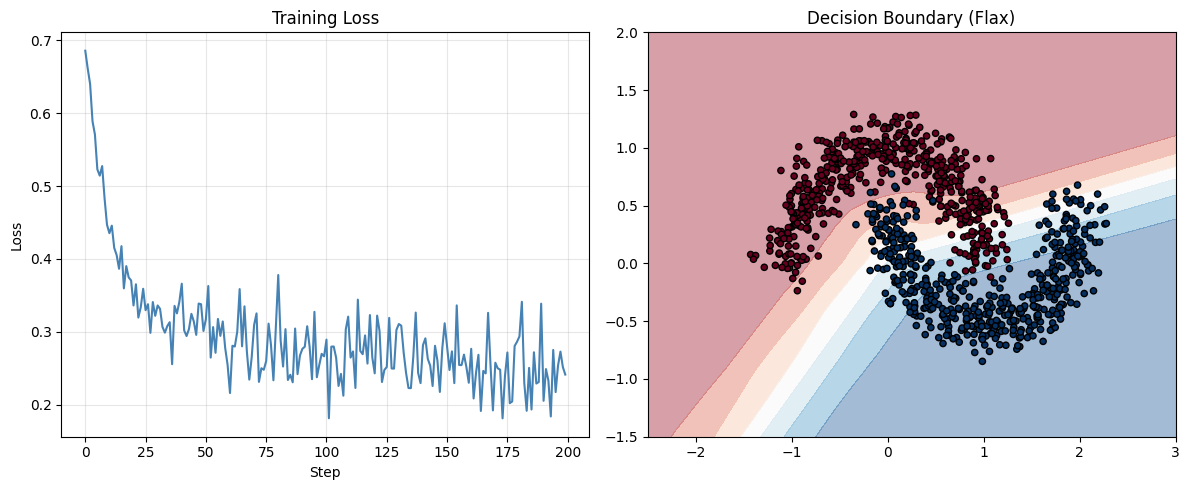

In [5]:
# @title Loss curve and decision boundary { display-mode: "form" }

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(losses_flax, color='steelblue')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss'); axes[0].grid(alpha=0.3)

xx, yy = np.meshgrid(np.linspace(-2.5, 3, 200), np.linspace(-1.5, 2, 200))
grid = jnp.array(np.c_[xx.ravel(), yy.ravel()], dtype=jnp.float32)
logits = model.apply({'params': params_flax}, grid)
probs = jax.nn.sigmoid(logits).reshape(xx.shape)
axes[1].contourf(xx, yy, np.array(probs), alpha=0.4, cmap='RdBu')
axes[1].scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='RdBu', edgecolors='k', s=20)
axes[1].set_title('Decision Boundary (Flax)')
plt.tight_layout(); plt.show()

---

# 2. Summary

## Key Takeaways

- **Flax doesn't change the JAX model**: `params` is still a pytree of arrays, `grad` still works, `tree.map` still updates.

- **`model.init(key, x_dummy)` returns `{'params': {...}}`**: a nested dict ready for `grad` and `jit`. The dummy input is used only to infer layer shapes.

- **`model.apply({'params': params}, x)` is a pure function**: safe to `jit`, `vmap`, and `grad` through. The training loop body is identical to the from-scratch version in Notebook 07.

- **`@nn.compact` defines layers inline**: the simpler of two Module styles. The other style declares layers in a separate `setup()` method; you only need it when several methods on the same Module have to reference the same layer object.

## What's Next

In **Notebook 09: Optax Optimization**, we'll swap the hand-rolled SGD update (`p - lr * g` inside a `tree.map`) for Optax's functional optimizer protocol, gaining Adam, learning rate schedules, and gradient clipping without changing anything else about the model.

---

# 3. Exercises

1. **Inspect params**: After `model.init`, print the full structure of `variables['params']`. How many layers are there? What are their names (`Dense_0`, `Dense_1`, etc.)?

2. **Different architecture**: Create a Flax MLP with 3 hidden layers of size 32. Initialize it and verify the param structure has 4 layers total (3 hidden + 1 output).

3. **Change activation**: Change the activation function in the `MLP` from `nn.relu` to `nn.sigmoid`. Re-initialize the model and check if the parameter shapes changed.